# 15. SCENIC+ Enhancer → Consensus Peak ID Mapping

**Goal:** Map enhancer regions identified by SCENIC+ eRegulons back to our cross-species consensus peak IDs (v3). This enables:
- Linking eRegulon enhancers to the unified peak nomenclature
- Classifying enhancers as unified (conserved) vs species-specific
- Cross-run robustness analysis (comparing multiple seeds)

In [1]:
import os
import re
import glob
import numpy as np
import pandas as pd
import pyranges as pr
import mudata as mu
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from itertools import combinations

plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')

## Configuration

In [3]:
BASE_DIR = "~/jjans/analysis/adult_intestine"
SCENICPLUS_DIR = os.path.join(BASE_DIR, "scenicplus")
CONSENSUS_DIR = os.path.join(BASE_DIR, "peaks/cross_species_consensus_v3/10_final")

SPECIES_LIST = ["Human", "Gorilla", "Chimpanzee", "Bonobo", "Macaque", "Marmoset"]

# Define SCENIC+ run directories to analyze.
# Each entry: (species, run_label, path_to_scplusmdata.h5mu)
# Edit this to match your completed runs.
RUNS = []
for species in SPECIES_LIST:
    # Check for existing completed runs (original + seed variants)
    # Original runs
    orig_mdata = os.path.join(SCENICPLUS_DIR, f"scplus_pipeline_{species}", "Snakemake", "scplusmdata.h5mu")
    if os.path.exists(orig_mdata):
        RUNS.append((species, "original", orig_mdata))
    
    # Seed/downsample variants
    pattern = os.path.join(SCENICPLUS_DIR, f"scplus_pipeline_{species}_seed*", "Snakemake", "scplusmdata.h5mu")
    for p in sorted(glob.glob(pattern)):
        run_label = Path(p).parent.parent.name.replace(f"scplus_pipeline_{species}_", "")
        RUNS.append((species, run_label, p))

# Output directory
OUTPUT_DIR = os.path.join(BASE_DIR, "peaks/cross_species_consensus_v3/scenic_enhancer_mapping")
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Found {len(RUNS)} completed SCENIC+ runs:")
for species, label, path in RUNS:
    print(f"  {species} / {label}")

Found 0 completed SCENIC+ runs:


## Helper functions

In [4]:
def load_consensus_peaks(species):
    """Load consensus peaks as PyRanges with peak IDs."""
    path = os.path.join(CONSENSUS_DIR, f"all_peaks_{species}.bed")
    df = pd.read_csv(path, sep="\t", header=None,
                     names=["Chromosome", "Start", "End", "peak_id"])
    return pr.PyRanges(df)


def extract_eregulon_regions(mdata_path):
    """
    Extract enhancer regions from SCENIC+ MuData eRegulon metadata.
    Returns DataFrame with columns: TF, region, target_gene, annotation_type.
    """
    mdata = mu.read(mdata_path)
    
    rows = []
    for annot_type in ["direct", "extended"]:
        key = f"{annot_type}_e_regulon_metadata"
        if key not in mdata.uns:
            print(f"  WARNING: {key} not found in MuData.")
            continue
        
        ereg_df = mdata.uns[key]
        if isinstance(ereg_df, pd.DataFrame):
            # Expected columns: TF, Region, Gene (may vary)
            for col_region in ["Region", "region", "regions"]:
                if col_region in ereg_df.columns:
                    break
            else:
                print(f"  WARNING: No region column found in {key}. Columns: {ereg_df.columns.tolist()}")
                continue
            
            for col_tf in ["TF", "tf", "Transcription_factor"]:
                if col_tf in ereg_df.columns:
                    break
            else:
                col_tf = ereg_df.columns[0]
            
            for col_gene in ["Gene", "gene", "target_gene"]:
                if col_gene in ereg_df.columns:
                    break
            else:
                col_gene = None
            
            for _, row in ereg_df.iterrows():
                rows.append({
                    "TF": row[col_tf],
                    "region": row[col_region],
                    "target_gene": row[col_gene] if col_gene else None,
                    "annotation_type": annot_type,
                })
    
    del mdata
    return pd.DataFrame(rows)

def extract_eregulon_regions_fast(run_dir):
    """
    Extract enhancer regions directly from TSVs to avoid loading the 275GB MuData object.
    Uses vectorized pandas operations for a 100x speedup.
    """
    rows = []
    # Note: adjust file names if they differ slightly (e.g., eRegulons_extended vs eRegulon_direct)
    for annot_type, file_name in [("direct", "eRegulon_direct.tsv"), ("extended", "eRegulons_extended.tsv")]:
        tsv_path = os.path.join(run_dir, "Snakemake", file_name)
        
        if not os.path.exists(tsv_path):
            print(f"  WARNING: {tsv_path} not found.")
            continue
            
        df = pd.read_csv(tsv_path, sep='\t')
        
        # Identify columns dynamically
        col_region = next((c for c in ["Region", "region", "regions"] if c in df.columns), None)
        col_tf = next((c for c in ["TF", "tf", "Transcription_factor"] if c in df.columns), None)
        col_gene = next((c for c in ["Gene", "gene", "target_gene"] if c in df.columns), None)
        
        if not col_region or not col_tf:
            print(f"  WARNING: Missing Region or TF column in {file_name}.")
            continue
            
        # Vectorized subsetting
        subset = df[[col_tf, col_region]].copy()
        subset.rename(columns={col_tf: "TF", col_region: "region"}, inplace=True)
        subset["target_gene"] = df[col_gene] if col_gene else None
        subset["annotation_type"] = annot_type
        
        rows.append(subset)
        
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

# You would update your loop to pass the run directory instead of the h5mu path:
# run_dir = Path(mdata_path).parent.parent
# ereg_df = extract_eregulon_regions_fast(run_dir)
def regions_to_pyranges(region_series):
    """Convert 'chr1:12345-67890' style regions to PyRanges."""
    parsed = region_series.str.extract(r"^(.+?):(\d+)-(\d+)$")
    parsed.columns = ["Chromosome", "Start", "End"]
    parsed["Start"] = parsed["Start"].astype(int)
    parsed["End"] = parsed["End"].astype(int)
    parsed["region"] = region_series.values
    return pr.PyRanges(parsed.dropna(subset=["Chromosome"]))


def map_regions_to_consensus(region_pr, consensus_pr):
    """Map regions to overlapping consensus peak IDs."""
    joined = region_pr.join(consensus_pr, how="left")
    jdf = joined.df
    if len(jdf) == 0:
        return pd.DataFrame(columns=["region", "peak_id"])
    result = jdf[["region", "peak_id"]].drop_duplicates()
    # pyranges 0.0.x uses -1 for unmatched left joins
    result = result[~result["peak_id"].isin([-1, "-1"])]
    return result

## Load consensus peaks

In [5]:
consensus_peaks = {}
for species in SPECIES_LIST:
    consensus_peaks[species] = load_consensus_peaks(species)
    print(f"{species}: {len(consensus_peaks[species]):,} consensus peaks")

Human: 1,039,336 consensus peaks
Gorilla: 1,013,198 consensus peaks
Chimpanzee: 1,029,053 consensus peaks
Bonobo: 992,889 consensus peaks
Macaque: 982,905 consensus peaks
Marmoset: 971,722 consensus peaks


## Process each SCENIC+ run

In [8]:
import os
import glob
import pandas as pd
import pyranges as pr
from pathlib import Path

import pandas as pd
import numpy as np
np.bool = bool      # <--- The magic band-aid for PyRanges
np.object = object  # Adding this one too, just in case PyRanges asks for it later
import pyranges as pr

import pandas as pd
import numpy as np

# --- ENVIRONMENT PATCHES FOR PYRANGES ---

# 1. Fix for NumPy 1.24+ (pyranges looks for np.bool)
np.bool = bool
np.object = object

# 2. Fix for Pandas 2.0+ (pyranges looks for df.append)
def _patch_append(self, other, ignore_index=False, verify_integrity=False, sort=False):
    # Route the old .append() calls to the new pd.concat() method
    if isinstance(other, dict):
        other = pd.DataFrame([other])
    elif isinstance(other, list):
        other = pd.DataFrame(other)
    return pd.concat([self, other], ignore_index=ignore_index, verify_integrity=verify_integrity, sort=sort)

pd.DataFrame.append = _patch_append
pd.Series.append = _patch_append

# Now we can safely import pyranges
import pyranges as pr
# ----------------------------------------

# --- Configuration ---
BASE_DIR = os.path.expanduser("~/jjans/analysis/adult_intestine")
SCENICPLUS_DIR = os.path.join(BASE_DIR, "scenicplus")
CONSENSUS_DIR = os.path.join(BASE_DIR, "peaks/cross_species_consensus_v3/10_final")
OUTPUT_DIR = os.path.join(BASE_DIR, "peaks/cross_species_consensus_v3/scenic_enhancer_mapping")

os.makedirs(OUTPUT_DIR, exist_ok=True)
SPECIES_LIST = ["Human", "Gorilla", "Chimpanzee", "Bonobo", "Macaque", "Marmoset"]

# --- 1. Discover Runs ---
# Updated to look for the Snakemake directory containing the TSVs, rather than the .h5mu file
RUNS = []
for species in SPECIES_LIST:
    # Original runs
    orig_snakemake_dir = os.path.join(SCENICPLUS_DIR, f"scplus_pipeline_{species}", "Snakemake")
    if os.path.exists(os.path.join(orig_snakemake_dir, "eRegulons_extended.tsv")):
        RUNS.append((species, "original", orig_snakemake_dir))
    
    # Seed/downsample variants
    pattern = os.path.join(SCENICPLUS_DIR, f"scplus_pipeline_{species}_seed*", "Snakemake")
    for p in sorted(glob.glob(pattern)):
        if os.path.exists(os.path.join(p, "eRegulons_extended.tsv")):
            run_label = Path(p).parent.name.replace(f"scplus_pipeline_{species}_", "")
            RUNS.append((species, run_label, p))

print(f"Found {len(RUNS)} completed SCENIC+ runs:")
for species, label, path in RUNS:
    print(f"  {species} / {label}")


# --- 2. Core Functions ---
def load_consensus_peaks(species):
    """Load consensus peaks as PyRanges with peak IDs."""
    path = os.path.join(CONSENSUS_DIR, f"all_peaks_{species}.bed")
    df = pd.read_csv(path, sep="\t", header=None,
                     names=["Chromosome", "Start", "End", "peak_id"])
    return pr.PyRanges(df)

def extract_eregulon_regions_fast(snakemake_dir):
    """
    Extract enhancer regions directly from TSVs to avoid loading the .h5mu object.
    Keeps all original columns (importance, rho, etc.) and standardizes core column names.
    """
    rows = []
    for annot_type, file_name in [("direct", "eRegulon_direct.tsv"), ("extended", "eRegulons_extended.tsv")]:
        tsv_path = os.path.join(snakemake_dir, file_name)
        
        if not os.path.exists(tsv_path):
            print(f"  WARNING: {tsv_path} not found.")
            continue
            
        df = pd.read_csv(tsv_path, sep='\t')
        
        # Dynamically map core columns while keeping all other stats
        col_mapping = {}
        for col in df.columns:
            if col in ["Region", "region", "regions"] and "region" not in col_mapping.values():
                col_mapping[col] = "region"
            elif col in ["TF", "tf", "Transcription_factor"] and "TF" not in col_mapping.values():
                col_mapping[col] = "TF"
            elif col in ["Gene", "gene", "target_gene"] and "target_gene" not in col_mapping.values():
                col_mapping[col] = "target_gene"
                
        df.rename(columns=col_mapping, inplace=True)
        df["annotation_type"] = annot_type
        rows.append(df)
        
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

def regions_to_pyranges(region_series):
    """Convert 'chr1:12345-67890' style regions to PyRanges."""
    parsed = region_series.str.extract(r"^(.+?):(\d+)-(\d+)$")
    parsed.columns = ["Chromosome", "Start", "End"]
    parsed["Start"] = parsed["Start"].astype(int)
    parsed["End"] = parsed["End"].astype(int)
    parsed["region"] = region_series.values
    return pr.PyRanges(parsed.dropna(subset=["Chromosome"]))

def map_regions_to_consensus(region_pr, consensus_pr):
    """Map regions to overlapping consensus peak IDs."""
    joined = region_pr.join(consensus_pr, how="left")
    jdf = joined.df
    if len(jdf) == 0:
        return pd.DataFrame(columns=["region", "peak_id"])
    result = jdf[["region", "peak_id"]].drop_duplicates()
    # pyranges 0.0.x uses -1 for unmatched left joins
    result = result[~result["peak_id"].isin([-1, "-1"])]
    return result


# --- 3. Main Execution ---
print("\nLoading consensus peaks...")
consensus_peaks = {}
for species in SPECIES_LIST:
    consensus_peaks[species] = load_consensus_peaks(species)
    print(f"  {species}: {len(consensus_peaks[species]):,} consensus peaks")

all_run_results = {}
run_stats = []

for species, run_label, snakemake_dir in RUNS:
    print(f"\n{'='*60}")
    print(f"  {species} / {run_label}")
    print(f"{'='*60}")
    
    # Extract eRegulon data using the fast TSV method
    ereg_df = extract_eregulon_regions_fast(snakemake_dir)
    if len(ereg_df) == 0:
        print("  No eRegulon regions found, skipping.")
        continue
    
    print(f"  eRegulon entries: {len(ereg_df):,}")
    print(f"  Unique TFs: {ereg_df['TF'].nunique()}")
    print(f"  Unique regions: {ereg_df['region'].nunique():,}")
    
    # Get unique regions and map to consensus
    unique_regions = ereg_df["region"].unique()
    region_pr = regions_to_pyranges(pd.Series(unique_regions))
    cons = consensus_peaks[species]
    
    mapping = map_regions_to_consensus(region_pr, cons)
    
    # Classify peak types
    if len(mapping) > 0:
        mapping["peak_type"] = mapping["peak_id"].apply(
            lambda x: "unified" if str(x).startswith("unified_") else
                      "human_specific" if str(x).startswith("human_peak_") else
                      "species_specific"
        )
    
    # Merge mapping back into the full eRegulon table
    ereg_annotated = ereg_df.merge(mapping, on="region", how="left")
    
    # Stats
    n_unique = len(unique_regions)
    n_mapped = mapping["region"].nunique() if len(mapping) > 0 else 0
    pct_mapped = n_mapped / n_unique * 100 if n_unique > 0 else 0
    
    print(f"\n  Mapping results:")
    print(f"    Unique enhancer regions: {n_unique:,}")
    print(f"    Mapped to consensus:     {n_mapped:,} ({pct_mapped:.1f}%)")
    print(f"    Unmapped:                {n_unique - n_mapped:,}")
    
    if len(mapping) > 0:
        pt_counts = mapping["peak_type"].value_counts()
        print(f"    Peak type breakdown (unique regions):")
        for pt, cnt in pt_counts.items():
            print(f"      {pt}: {cnt:,}")
    
    # Save annotated eRegulon table
    out_path = os.path.join(OUTPUT_DIR, f"eRegulon_peaks_annotated_{species}_{run_label}.tsv")
    ereg_annotated.to_csv(out_path, sep="\t", index=False)
    print(f"  Saved: {out_path}")
    
    # Store for further in-memory analysis
    run_key = f"{species}_{run_label}"
    all_run_results[run_key] = {
        "ereg_annotated": ereg_annotated,
        "mapping": mapping,
        "unique_regions": set(unique_regions),
    }
    
    run_stats.append({
        "species": species,
        "run_label": run_label,
        "n_eregulon_entries": len(ereg_df),
        "n_unique_regions": n_unique,
        "n_unique_TFs": ereg_df["TF"].nunique(),
        "n_mapped": n_mapped,
        "pct_mapped": pct_mapped,
    })

stats_df = pd.DataFrame(run_stats)
print("\nProcessing complete.")

Found 6 completed SCENIC+ runs:
  Human / original
  Gorilla / original
  Chimpanzee / original
  Bonobo / original
  Macaque / original
  Marmoset / original

Loading consensus peaks...
  Human: 1,039,336 consensus peaks
  Gorilla: 1,013,198 consensus peaks
  Chimpanzee: 1,029,053 consensus peaks
  Bonobo: 992,889 consensus peaks
  Macaque: 982,905 consensus peaks
  Marmoset: 971,722 consensus peaks

  Human / original
  eRegulon entries: 325,458
  Unique TFs: 257
  Unique regions: 81,592

  Mapping results:
    Unique enhancer regions: 81,592
    Mapped to consensus:     81,089 (99.4%)
    Unmapped:                503
    Peak type breakdown (unique regions):
      unified: 109,071
      human_specific: 145
  Saved: /cluster/home/jjanssens/jjans/analysis/adult_intestine/peaks/cross_species_consensus_v3/scenic_enhancer_mapping/eRegulon_peaks_annotated_Human_original.tsv

  Gorilla / original
  eRegulon entries: 271,590
  Unique TFs: 164
  Unique regions: 77,466

  Mapping results:
   

In [11]:
import os
import glob
import pandas as pd
import numpy as np
from pathlib import Path

# --- ENVIRONMENT PATCHES FOR PYRANGES ---
# 1. Fix for NumPy 1.24+ (pyranges looks for np.bool)
np.bool = bool
np.object = object

# 2. Fix for Pandas 2.0+ (pyranges looks for df.append)
def _patch_append(self, other, ignore_index=False, verify_integrity=False, sort=False):
    if isinstance(other, dict):
        other = pd.DataFrame([other])
    elif isinstance(other, list):
        other = pd.DataFrame(other)
    return pd.concat([self, other], ignore_index=ignore_index, verify_integrity=verify_integrity, sort=sort)

pd.DataFrame.append = _patch_append
pd.Series.append = _patch_append

# Now we can safely import pyranges
import pyranges as pr
# ----------------------------------------

# --- Configuration ---
BASE_DIR = os.path.expanduser("~/jjans/analysis/adult_intestine")
SCENICPLUS_DIR = os.path.join(BASE_DIR, "scenicplus")
CONSENSUS_DIR = os.path.join(BASE_DIR, "peaks/cross_species_consensus_v3/10_final")
OUTPUT_DIR = os.path.join(BASE_DIR, "peaks/cross_species_consensus_v3/scenic_enhancer_mapping")

os.makedirs(OUTPUT_DIR, exist_ok=True)
SPECIES_LIST = ["Human", "Gorilla", "Chimpanzee", "Bonobo", "Macaque", "Marmoset"]

# --- 1. Discover Runs ---
RUNS = []
for species in SPECIES_LIST:
    # Original runs
    orig_snakemake_dir = os.path.join(SCENICPLUS_DIR, f"scplus_pipeline_{species}", "Snakemake")
    if os.path.exists(os.path.join(orig_snakemake_dir, "eRegulons_extended.tsv")):
        RUNS.append((species, "original", orig_snakemake_dir))
    
    # Seed/downsample variants
    pattern = os.path.join(SCENICPLUS_DIR, f"scplus_pipeline_{species}_seed*", "Snakemake")
    for p in sorted(glob.glob(pattern)):
        if os.path.exists(os.path.join(p, "eRegulons_extended.tsv")):
            run_label = Path(p).parent.name.replace(f"scplus_pipeline_{species}_", "")
            RUNS.append((species, run_label, p))

print(f"Found {len(RUNS)} completed SCENIC+ runs:")
for species, label, path in RUNS:
    print(f"  {species} / {label}")


# --- 2. Core Functions ---

def normalize_chromosomes(chrom_series):
    """
    NEW: Ensures all chromosome names uniformly start with 'chr' 
    to prevent cross-species mapping failures (e.g., '1' vs 'chr1').
    """
    return chrom_series.astype(str).apply(lambda x: x if x.startswith("chr") else f"chr{x}")


def load_consensus_peaks(species):
    """Load consensus peaks as PyRanges with peak IDs."""
    path = os.path.join(CONSENSUS_DIR, f"all_peaks_{species}.bed")
    df = pd.read_csv(path, sep="\t", header=None,
                     names=["Chromosome", "Start", "End", "peak_id"])
    
    # Apply chromosome normalization
    df["Chromosome"] = normalize_chromosomes(df["Chromosome"])
    return pr.PyRanges(df)

def extract_eregulon_regions_fast(snakemake_dir):
    """Extract enhancer regions directly from TSVs."""
    rows = []
    for annot_type, file_name in [("direct", "eRegulon_direct.tsv"), ("extended", "eRegulons_extended.tsv")]:
        tsv_path = os.path.join(snakemake_dir, file_name)
        
        if not os.path.exists(tsv_path):
            print(f"  WARNING: {tsv_path} not found.")
            continue
            
        df = pd.read_csv(tsv_path, sep='\t')
        
        col_mapping = {}
        for col in df.columns:
            if col in ["Region", "region", "regions"] and "region" not in col_mapping.values():
                col_mapping[col] = "region"
            elif col in ["TF", "tf", "Transcription_factor"] and "TF" not in col_mapping.values():
                col_mapping[col] = "TF"
            elif col in ["Gene", "gene", "target_gene"] and "target_gene" not in col_mapping.values():
                col_mapping[col] = "target_gene"
                
        df.rename(columns=col_mapping, inplace=True)
        df["annotation_type"] = annot_type
        rows.append(df)
        
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

def regions_to_pyranges(region_series):
    """Convert 'chr1:12345-67890' style regions to PyRanges."""
    parsed = region_series.str.extract(r"^(.+?):(\d+)-(\d+)$")
    parsed.columns = ["Chromosome", "Start", "End"]
    parsed["Start"] = parsed["Start"].astype(int)
    parsed["End"] = parsed["End"].astype(int)
    parsed["region"] = region_series.values
    
    # Apply chromosome normalization
    parsed["Chromosome"] = normalize_chromosomes(parsed["Chromosome"])
    
    return pr.PyRanges(parsed.dropna(subset=["Chromosome"]))

def map_regions_to_consensus(region_pr, consensus_pr):
    """Map regions to overlapping consensus peak IDs."""
    joined = region_pr.join(consensus_pr, how="left")
    jdf = joined.df
    if len(jdf) == 0:
        return pd.DataFrame(columns=["region", "peak_id"])
    result = jdf[["region", "peak_id"]].drop_duplicates()
    result = result[~result["peak_id"].isin([-1, "-1"])]
    return result


# --- 3. Main Execution ---
print("\nLoading consensus peaks...")
consensus_peaks = {}
for species in SPECIES_LIST:
    consensus_peaks[species] = load_consensus_peaks(species)
    print(f"  {species}: {len(consensus_peaks[species]):,} consensus peaks")

all_run_results = {}
run_stats = []

for species, run_label, snakemake_dir in RUNS:
    print(f"\n{'='*60}")
    print(f"  {species} / {run_label}")
    print(f"{'='*60}")
    
    ereg_df = extract_eregulon_regions_fast(snakemake_dir)
    if len(ereg_df) == 0:
        print("  No eRegulon regions found, skipping.")
        continue
    
    print(f"  eRegulon entries: {len(ereg_df):,}")
    print(f"  Unique TFs: {ereg_df['TF'].nunique()}")
    print(f"  Unique regions: {ereg_df['region'].nunique():,}")
    
    unique_regions = ereg_df["region"].unique()
    region_pr = regions_to_pyranges(pd.Series(unique_regions))
    cons = consensus_peaks[species]
    
    mapping = map_regions_to_consensus(region_pr, cons)
    
    if len(mapping) > 0:
        mapping["peak_type"] = mapping["peak_id"].apply(
            lambda x: "unified" if str(x).startswith("unified_") else
                      "human_specific" if str(x).startswith("human_peak_") else
                      "species_specific"
        )
    
    ereg_annotated = ereg_df.merge(mapping, on="region", how="left")
    
    n_unique = len(unique_regions)
    n_mapped = mapping["region"].nunique() if len(mapping) > 0 else 0
    pct_mapped = n_mapped / n_unique * 100 if n_unique > 0 else 0
    
    print(f"\n  Mapping results:")
    print(f"    Unique enhancer regions: {n_unique:,}")
    print(f"    Mapped to consensus:     {n_mapped:,} ({pct_mapped:.1f}%)")
    print(f"    Unmapped:                {n_unique - n_mapped:,}")
    
    if len(mapping) > 0:
        pt_counts = mapping["peak_type"].value_counts()
        print(f"    Peak type breakdown (unique regions):")
        for pt, cnt in pt_counts.items():
            print(f"      {pt}: {cnt:,}")
    
    out_path = os.path.join(OUTPUT_DIR, f"eRegulon_peaks_annotated_{species}_{run_label}.tsv")
    ereg_annotated.to_csv(out_path, sep="\t", index=False)
    print(f"  Saved: {out_path}")
    
    run_key = f"{species}_{run_label}"
    all_run_results[run_key] = {
        "ereg_annotated": ereg_annotated,
        "mapping": mapping,
        "unique_regions": set(unique_regions),
    }
    
    run_stats.append({
        "species": species,
        "run_label": run_label,
        "n_eregulon_entries": len(ereg_df),
        "n_unique_regions": n_unique,
        "n_unique_TFs": ereg_df["TF"].nunique(),
        "n_mapped": n_mapped,
        "pct_mapped": pct_mapped,
    })

stats_df = pd.DataFrame(run_stats)
print("\nProcessing complete.")

Found 6 completed SCENIC+ runs:
  Human / original
  Gorilla / original
  Chimpanzee / original
  Bonobo / original
  Macaque / original
  Marmoset / original

Loading consensus peaks...
  Human: 1,039,336 consensus peaks
  Gorilla: 1,013,198 consensus peaks
  Chimpanzee: 1,029,053 consensus peaks
  Bonobo: 992,889 consensus peaks
  Macaque: 982,905 consensus peaks
  Marmoset: 971,722 consensus peaks

  Human / original
  eRegulon entries: 325,458
  Unique TFs: 257
  Unique regions: 81,592

  Mapping results:
    Unique enhancer regions: 81,592
    Mapped to consensus:     81,089 (99.4%)
    Unmapped:                503
    Peak type breakdown (unique regions):
      unified: 109,071
      human_specific: 145
  Saved: /cluster/home/jjanssens/jjans/analysis/adult_intestine/peaks/cross_species_consensus_v3/scenic_enhancer_mapping/eRegulon_peaks_annotated_Human_original.tsv

  Gorilla / original
  eRegulon entries: 271,590
  Unique TFs: 164
  Unique regions: 77,466

  Mapping results:
   

## Summary across runs

In [12]:
if len(stats_df) > 0:
    display(stats_df.style.format({"pct_mapped": "{:.1f}%"}))
else:
    print("No completed runs found.")

,species,run_label,n_eregulon_entries,n_unique_regions,n_unique_TFs,n_mapped,pct_mapped
0,Human,original,325458,81592,257,81089,99.4%
1,Gorilla,original,271590,77466,164,75868,97.9%
2,Chimpanzee,original,270453,70495,178,69583,98.7%
3,Bonobo,original,250673,58291,126,57515,98.7%
4,Macaque,original,184384,47897,153,47257,98.7%
5,Marmoset,original,226620,69251,166,65922,95.2%


## Per-TF conservation analysis

For each TF's enhancer regions, what fraction are unified (cross-species conserved) vs species-specific?


--- Human_original ---
  Top 15 TFs by % unified enhancers (min 10 peaks):


peak_type,human_specific,unified,total,pct_unified
TF,,,,
AHCTF1,0,38,38,100.0
IRF8,0,15,15,100.0
NR2C2,0,238,238,100.0
NR2F6,0,107,107,100.0
NR3C1,0,99,99,100.0
NR3C2,0,223,223,100.0
NR4A1,0,19,19,100.0
ONECUT2,0,43,43,100.0
PAX5,0,23,23,100.0


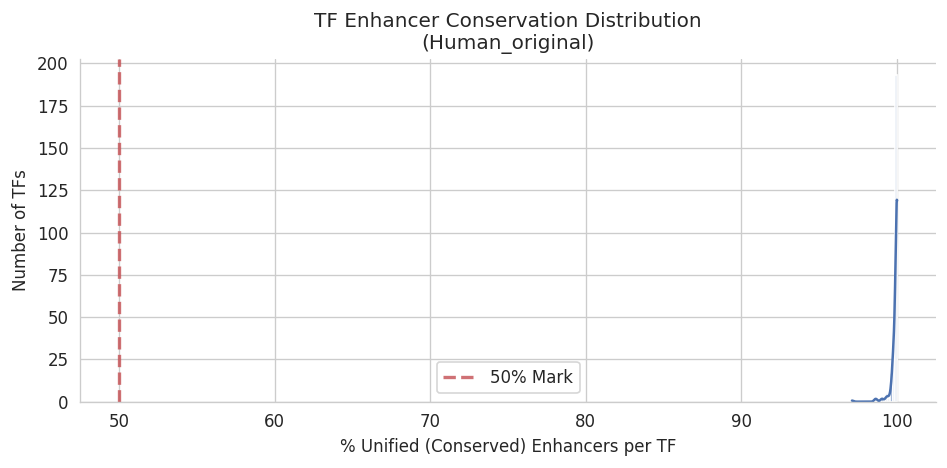


--- Gorilla_original ---
  Top 15 TFs by % unified enhancers (min 10 peaks):


peak_type,species_specific,unified,total,pct_unified
TF,,,,
SOX8,0,25,25,100.0
E2F4,0,47,47,100.0
EOMES,0,22,22,100.0
STAT1,0,14,14,100.0
ETV3,0,20,20,100.0
SREBF2,0,10,10,100.0
SREBF1,0,25,25,100.0
MYNN,0,31,31,100.0
SOX6,0,99,99,100.0


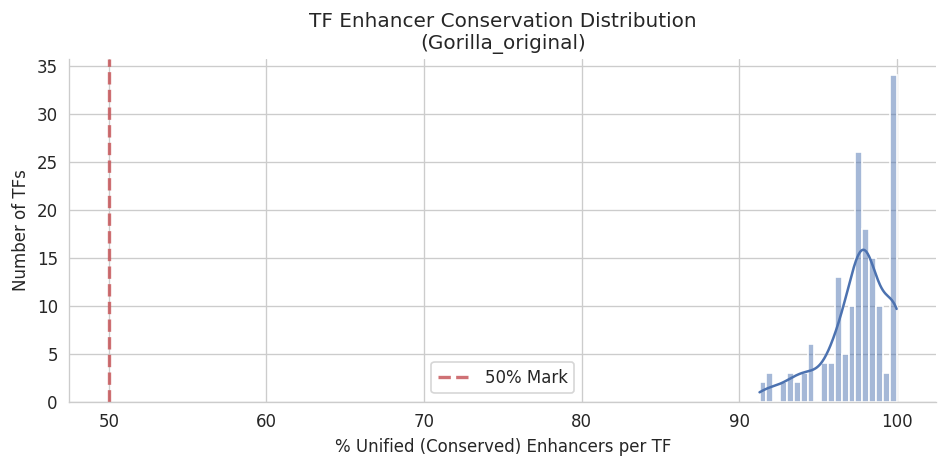


--- Chimpanzee_original ---
  Top 15 TFs by % unified enhancers (min 10 peaks):


peak_type,species_specific,unified,total,pct_unified
TF,,,,
ARID3A,0,38,38,100.0
MITF,0,61,61,100.0
POU2F1,0,58,58,100.0
NR3C2,0,10,10,100.0
NR2C2,0,10,10,100.0
NKX2-2,0,29,29,100.0
NFIC,0,12,12,100.0
NFE2L1,0,19,19,100.0
NFATC1,0,26,26,100.0


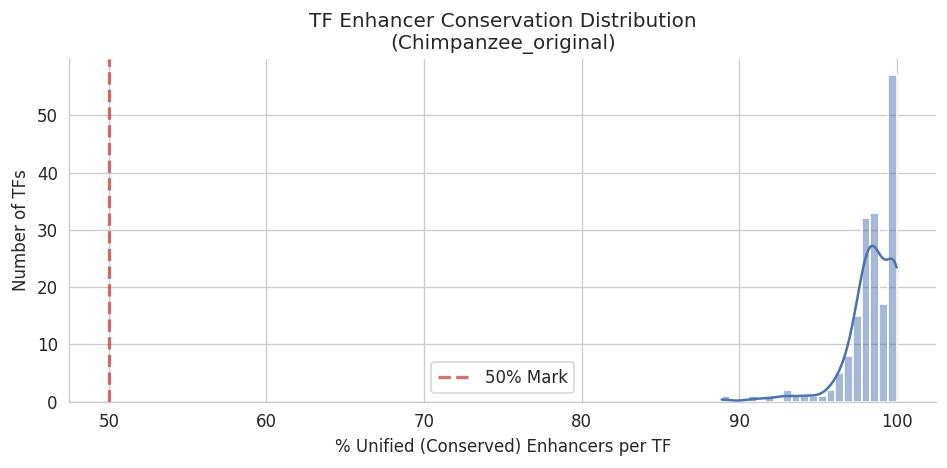


--- Bonobo_original ---
  Top 15 TFs by % unified enhancers (min 10 peaks):


peak_type,species_specific,unified,total,pct_unified
TF,,,,
ATF4,0,16,16,100.0
SP1,0,58,58,100.0
PAXIP1,0,20,20,100.0
NFIC,0,44,44,100.0
NFE2L1,0,10,10,100.0
BACH1,0,27,27,100.0
PRDM16,0,23,23,100.0
ISX,0,63,63,100.0
HOXA3,0,15,15,100.0


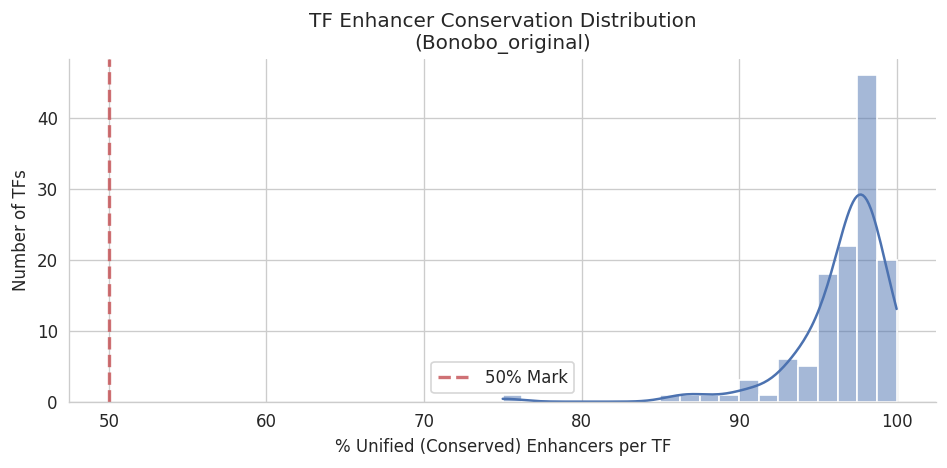


--- Macaque_original ---
  Top 15 TFs by % unified enhancers (min 10 peaks):


peak_type,species_specific,unified,total,pct_unified
TF,,,,
SIRT6,0,17,17,100.0
SOX10,0,38,38,100.0
MAZ,0,14,14,100.0
MXI1,0,19,19,100.0
KLF13,0,17,17,100.0
NFKB1,0,10,10,100.0
IKZF2,0,17,17,100.0
FOXP4,0,46,46,100.0
PKNOX1,0,11,11,100.0


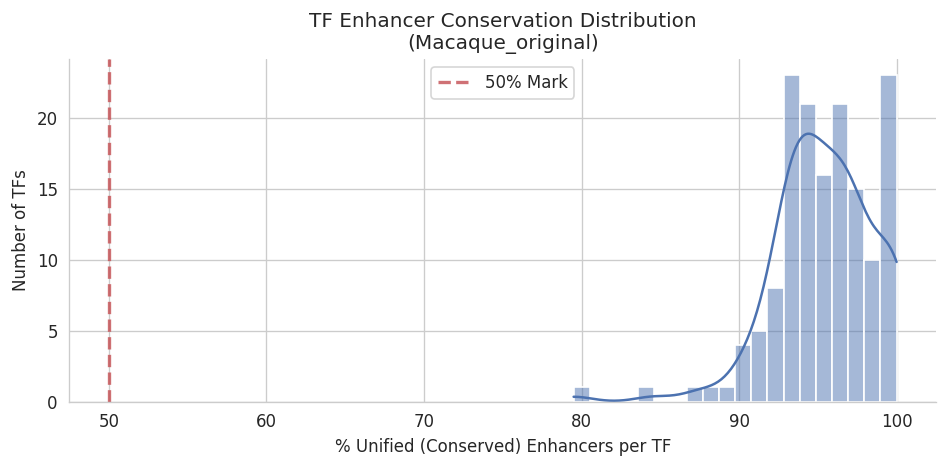


--- Marmoset_original ---
  Top 15 TFs by % unified enhancers (min 10 peaks):


peak_type,species_specific,unified,total,pct_unified
TF,,,,
HOXA10,0,17,17,100.0
ATF4,0,16,16,100.0
ZNF180,0,11,11,100.0
MESP1,0,13,13,100.0
REL,1,51,52,98.1
CHD2,16,633,649,97.5
RFX2,1,36,37,97.3
MECP2,1,29,30,96.7
ATF7,1,28,29,96.6


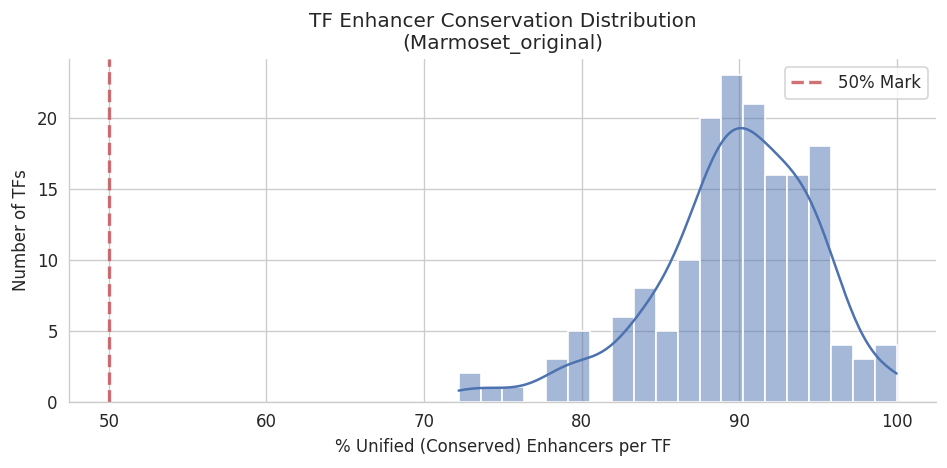

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Set a threshold to filter out TFs with too few enhancers (removes 100% noise)
MIN_PEAKS = 10 

for run_key, result in all_run_results.items():
    ereg = result["ereg_annotated"]
    
    # Ensure we actually have mapped peaks
    if "peak_type" not in ereg.columns or ereg["peak_type"].isna().all():
        print(f"\n--- {run_key} ---")
        print("  No peak_type annotations found. Skipping.")
        continue
    
    print(f"\n{'='*50}")
    print(f"--- {run_key} ---")
    print(f"{'='*50}")
    
    # Per-TF: count unique regions by peak type
    tf_stats = (
        ereg.dropna(subset=["peak_id"])
        .drop_duplicates(subset=["TF", "region", "peak_type"])
        .groupby(["TF", "peak_type"])
        .size()
        .unstack(fill_value=0)
    )
    
    if "unified" in tf_stats.columns:
        # Calculate total BEFORE filtering
        tf_stats["total"] = tf_stats.sum(axis=1)
        
        # --- THE FIX: Filter out TFs with too few peaks ---
        tf_stats = tf_stats[tf_stats["total"] >= MIN_PEAKS].copy()
        
        # Calculate percentages
        tf_stats["pct_unified"] = (tf_stats["unified"] / tf_stats["total"] * 100).round(1)
        tf_stats = tf_stats.sort_values("pct_unified", ascending=False)
        
        print(f"  Top 15 TFs by % unified enhancers (min {MIN_PEAKS} peaks):")
        display(tf_stats.head(15))
        
        # Plot distribution using Seaborn for better aesthetics
        fig, ax = plt.subplots(figsize=(8, 4))
        sns.histplot(data=tf_stats, x="pct_unified", bins=20, 
                     kde=True, color="#4C72B0", edgecolor="white", ax=ax)
        
        ax.set_xlabel("% Unified (Conserved) Enhancers per TF")
        ax.set_ylabel("Number of TFs")
        ax.set_title(f"TF Enhancer Conservation Distribution\n({run_key})")
        ax.axvline(50, ls="--", color="#C44E52", alpha=0.8, linewidth=2, label="50% Mark")
        ax.legend()
        
        sns.despine()
        plt.tight_layout()
        plt.show()
    else:
        print("  No 'unified' peaks found for this run.")

Top TFs driving species-specific enhancers (Min 10 total enhancers)

--- Human Top 5 Evolutionary Drivers ---


peak_type,TF,total,specific_count,pct_specific
245,ZNF215,34,1,2.9
242,ZFHX3,72,1,1.4
211,STAT4,70,1,1.4
15,BHLHE40,79,1,1.3
234,XBP1,104,1,1.0



--- Gorilla Top 5 Evolutionary Drivers ---


peak_type,TF,total,specific_count,pct_specific
377,SOX4,23,2,8.7
416,ZNF41,12,1,8.3
390,TAF1,37,3,8.1
414,ZNF385D,25,2,8.0
272,CREB3L2,25,2,8.0



--- Chimpanzee Top 5 Evolutionary Drivers ---


...

peak_type,TF,total,specific_count,pct_specific
600,BARX2,12,3,25.0
661,MEF2B,80,11,13.8
721,ZNF69,15,2,13.3
719,ZNF367,25,3,12.0
613,EBF1,48,5,10.4



--- Macaque Top 5 Evolutionary Drivers ---


peak_type,TF,total,specific_count,pct_specific
736,CPEB1,44,9,20.5
871,ZNF518A,13,2,15.4
751,ESR1,71,9,12.7
794,MEF2A,123,15,12.2
796,MEIS2,121,13,10.7



--- Marmoset Top 5 Evolutionary Drivers ---


peak_type,TF,total,specific_count,pct_specific
883,BARX2,90,25,27.8
941,KDM5A,89,24,27.0
916,FOXK2,35,9,25.7
974,NR2C1,33,8,24.2
997,REST,214,46,21.5


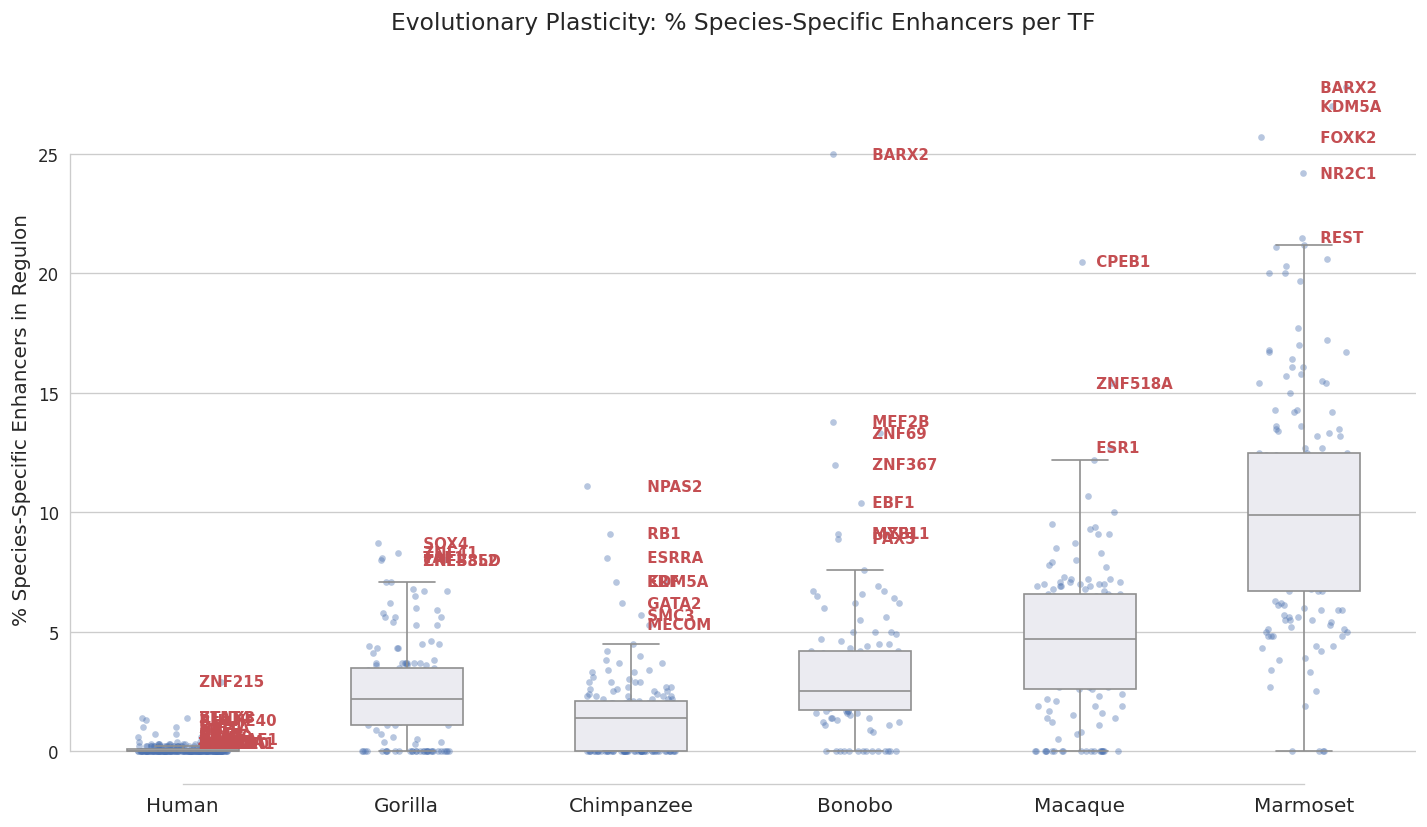

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import numpy as np

# Set a threshold to filter out TFs with too few enhancers
MIN_PEAKS = 10 

combined_tf_stats = []

for run_key, result in all_run_results.items():
    # Only use the "original" runs for this plot to avoid duplicating data with seed variants
    if "original" not in run_key:
        continue
        
    species = run_key.split("_")[0]
    ereg = result["ereg_annotated"]
    
    if "peak_type" not in ereg.columns or ereg["peak_type"].isna().all():
        continue
        
    # Per-TF: count unique regions by peak type
    tf_counts = (
        ereg.dropna(subset=["peak_id"])
        .drop_duplicates(subset=["TF", "region", "peak_type"])
        .groupby(["TF", "peak_type"])
        .size()
        .unstack(fill_value=0)
    )
    
    # Ensure our target columns exist even if a species has 0 of them
    for col in ["unified", "human_specific", "species_specific"]:
        if col not in tf_counts.columns:
            tf_counts[col] = 0
            
    # Calculate total and filter out low-peak TFs
    tf_counts["total"] = tf_counts.sum(axis=1)
    tf_counts = tf_counts[tf_counts["total"] >= MIN_PEAKS].copy()
    
    if len(tf_counts) == 0:
        continue
        
    # Determine the specific column based on the species
    specific_col = "human_specific" if species == "Human" else "species_specific"
        
    tf_counts["specific_count"] = tf_counts[specific_col]
    tf_counts["pct_specific"] = (tf_counts["specific_count"] / tf_counts["total"] * 100).round(1)
    
    # Flatten the index so we can use it in Seaborn
    tf_counts = tf_counts.reset_index()
    tf_counts["species"] = species
    
    combined_tf_stats.append(tf_counts)

# --- 2. Combine and Plot ---
if combined_tf_stats:
    df_plot = pd.concat(combined_tf_stats, ignore_index=True)
    
    # Print the top 5 TFs for each species
    print(f"Top TFs driving species-specific enhancers (Min {MIN_PEAKS} total enhancers)")
    print("="*75)
    for sp in df_plot["species"].unique():
        sp_data = df_plot[df_plot["species"] == sp].sort_values("pct_specific", ascending=False)
        print(f"\n--- {sp} Top 5 Evolutionary Drivers ---")
        display(sp_data[["TF", "total", "specific_count", "pct_specific"]].head(5))

    # Create the Plot
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Draw the boxplot (hide outliers here so we can custom-draw them later)
    sns.boxplot(data=df_plot, x="species", y="pct_specific", 
                color="#EAEAF2", width=0.5, fliersize=0, ax=ax)
    
    # Add a stripplot to show the underlying distribution of all TFs
    sns.stripplot(data=df_plot, x="species", y="pct_specific", 
                  alpha=0.4, jitter=0.2, color="#4C72B0", size=4, ax=ax, zorder=1)

    # --- 3. Annotate the Outliers ---
    # We use the standard IQR method to find statistical outliers
    for i, sp in enumerate(df_plot["species"].unique()):
        sp_data = df_plot[df_plot["species"] == sp]
        if len(sp_data) == 0: continue
        
        Q1 = sp_data["pct_specific"].quantile(0.25)
        Q3 = sp_data["pct_specific"].quantile(0.75)
        IQR = Q3 - Q1
        outlier_thresh = Q3 + 1.5 * IQR
        
        # Isolate the outlier TFs
        outliers = sp_data[sp_data["pct_specific"] > outlier_thresh]
        
        # Annotate them on the plot
        for _, row in outliers.iterrows():
            ax.text(i + 0.05, row["pct_specific"], f" {row['TF']}", 
                    fontsize=9, va='center', ha='left', color='#C44E52', 
                    fontweight='bold', zorder=5)

    # Styling
    ax.set_title("Evolutionary Plasticity: % Species-Specific Enhancers per TF", fontsize=14, pad=15)
    ax.set_ylabel("% Species-Specific Enhancers in Regulon", fontsize=12)
    ax.set_xlabel("")
    ax.tick_params(axis='x', labelsize=12)
    
    sns.despine(trim=True)
    plt.tight_layout()
    plt.show()

else:
    print("No data available to plot. Check if the mapping step completed successfully.")


ENHANCER-GENE LINK CONSERVATION SUMMARY


,Number of Species Sharing Link,Total Enhancer-Gene Pairs
0,1,356440
1,2,88285
2,3,34688
3,4,14114
4,5,5478
5,6,1586



Found 1,586 core enhancer-gene links conserved across all 6 species.
Here are the top 10:


,peak_id,target_gene,species_count,species_list
92728,unified_117227,A1CF,6,"Bonobo, Chimpanzee, Gorilla, Human, Macaque, M..."
247831,unified_416724,ABCC3,6,"Bonobo, Chimpanzee, Gorilla, Human, Macaque, M..."
248111,unified_416915,ABCC3,6,"Bonobo, Chimpanzee, Gorilla, Human, Macaque, M..."
401664,unified_744673,ABHD18,6,"Bonobo, Chimpanzee, Gorilla, Human, Macaque, M..."
419944,unified_799434,ABLIM3,6,"Bonobo, Chimpanzee, Gorilla, Human, Macaque, M..."
419957,unified_799447,ABLIM3,6,"Bonobo, Chimpanzee, Gorilla, Human, Macaque, M..."
419974,unified_799456,ABLIM3,6,"Bonobo, Chimpanzee, Gorilla, Human, Macaque, M..."
114486,unified_164526,ABTB2,6,"Bonobo, Chimpanzee, Gorilla, Human, Macaque, M..."
265667,unified_450076,ACAA2,6,"Bonobo, Chimpanzee, Gorilla, Human, Macaque, M..."
238933,unified_406837,ACACA,6,"Bonobo, Chimpanzee, Gorilla, Human, Macaque, M..."


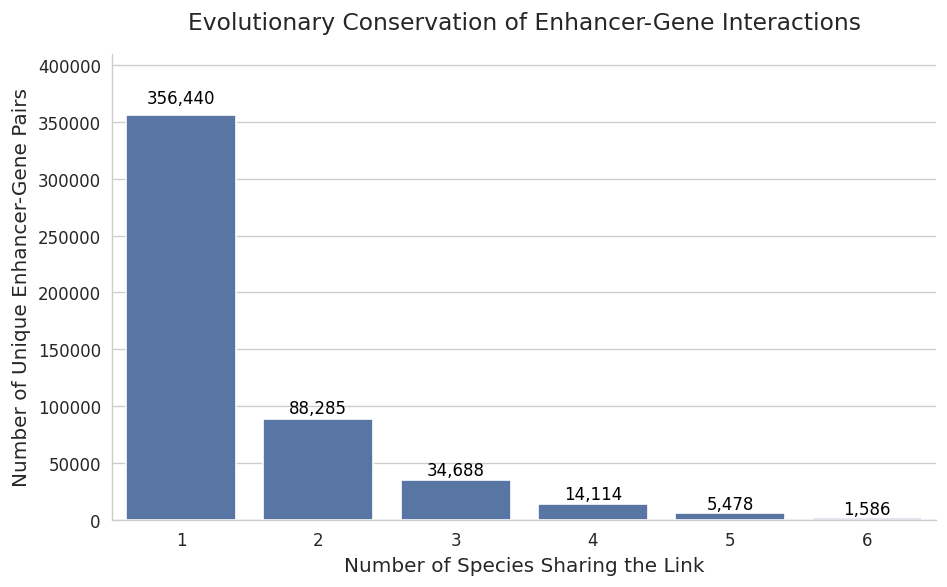

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# 1. Gather all unique Enhancer-Gene links per species
link_records = []

for run_key, result in all_run_results.items():
    # Only use the "original" runs to avoid double-counting seed variants
    if "original" not in run_key:
        continue
        
    species = run_key.split("_")[0]
    ereg = result["ereg_annotated"]
    
    if "peak_id" not in ereg.columns:
        continue
        
    # Drop rows without a mapped consensus peak or target gene
    valid_links = ereg.dropna(subset=["peak_id", "target_gene"])
    
    # We only care if the link exists in this species, regardless of which/how many TFs drive it
    unique_links = valid_links[["peak_id", "target_gene"]].drop_duplicates().copy()
    unique_links["species"] = species
    
    link_records.append(unique_links)

# 2. Combine and Count
if link_records:
    all_links_df = pd.concat(link_records, ignore_index=True)
    
    # Count how many unique species share each link
    link_conservation = (
        all_links_df.groupby(["peak_id", "target_gene"])["species"]
        .nunique()
        .reset_index(name="species_count")
    )
    
    # Optional but highly useful: keep a string of WHICH species share the link
    species_present = (
        all_links_df.groupby(["peak_id", "target_gene"])["species"]
        .apply(lambda x: ", ".join(sorted(x)))
        .reset_index(name="species_list")
    )
    link_conservation = link_conservation.merge(species_present, on=["peak_id", "target_gene"])
    
    # Sort by the most conserved links first
    link_conservation = link_conservation.sort_values(by=["species_count", "target_gene"], ascending=[False, True])

    # 3. Summary Statistics
    conservation_dist = link_conservation["species_count"].value_counts().sort_index()
    
    print("\n" + "="*60)
    print("ENHANCER-GENE LINK CONSERVATION SUMMARY")
    print("="*60)
    
    dist_df = conservation_dist.reset_index()
    dist_df.columns = ["Number of Species Sharing Link", "Total Enhancer-Gene Pairs"]
    display(dist_df)
    
    max_species = link_conservation["species_count"].max()
    highly_conserved = link_conservation[link_conservation["species_count"] == max_species]
    
    print(f"\nFound {len(highly_conserved):,} core enhancer-gene links conserved across all {max_species} species.")
    print("Here are the top 10:")
    display(highly_conserved.head(10))

    # 4. Plotting the Distribution
    fig, ax = plt.subplots(figsize=(8, 5))
    
    # Create the bar plot
    bars = sns.barplot(
        x=conservation_dist.index, 
        y=conservation_dist.values, 
        color="#4C72B0", 
        ax=ax
    )
    
    # Add actual numbers on top of the bars
    for i, v in enumerate(conservation_dist.values):
        ax.text(i, v + (v * 0.02), f"{v:,}", ha='center', va='bottom', fontsize=10, color='black')
        
    ax.set_title("Evolutionary Conservation of Enhancer-Gene Interactions", fontsize=14, pad=15)
    ax.set_xlabel("Number of Species Sharing the Link", fontsize=12)
    ax.set_ylabel("Number of Unique Enhancer-Gene Pairs", fontsize=12)
    
    # Adjust y-limit slightly to fit the text labels
    ax.set_ylim(0, conservation_dist.values.max() * 1.15)
    
    sns.despine()
    plt.tight_layout()
    plt.show()

else:
    print("No valid enhancer-gene links found across the runs.")


ENHANCER-GENE LINK: CONSERVATION vs. STRENGTH

Top 10 Strongest Core Links (Conserved in all 6 species):


,peak_id,target_gene,species_count,avg_strength,species_list
83768,unified_1023254,DIPK2B,6,0.091051,"Bonobo, Chimpanzee, Gorilla, Human, Macaque, M..."
423736,unified_806458,DOCK2,6,0.090227,"Bonobo, Chimpanzee, Gorilla, Human, Macaque, M..."
85796,unified_1027789,POF1B,6,0.084082,"Bonobo, Chimpanzee, Gorilla, Human, Macaque, M..."
66730,unified_085849,ESRRG,6,0.078719,"Bonobo, Chimpanzee, Gorilla, Human, Macaque, M..."
423734,unified_806457,DOCK2,6,0.074803,"Bonobo, Chimpanzee, Gorilla, Human, Macaque, M..."
84987,unified_1025771,HEPH,6,0.074123,"Bonobo, Chimpanzee, Gorilla, Human, Macaque, M..."
85783,unified_1027775,POF1B,6,0.072648,"Bonobo, Chimpanzee, Gorilla, Human, Macaque, M..."
316123,unified_543583,ARHGAP15,6,0.069448,"Bonobo, Chimpanzee, Gorilla, Human, Macaque, M..."
316125,unified_543584,ARHGAP15,6,0.068182,"Bonobo, Chimpanzee, Gorilla, Human, Macaque, M..."
91224,unified_111453,ZEB1,6,0.058594,"Bonobo, Chimpanzee, Gorilla, Human, Macaque, M..."


/scratch/tmp.60523404.jjanssens/ipykernel_476181/1951578521.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


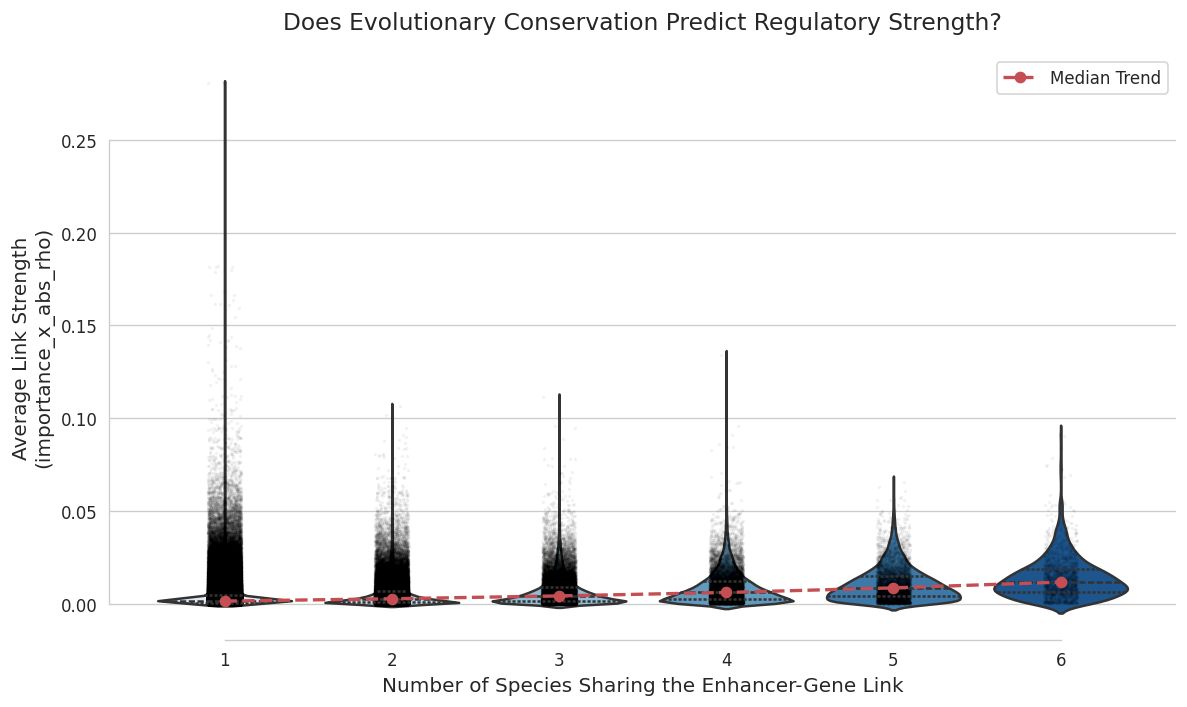

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# The column representing the strength of the Enhancer -> Gene link
# (You can change this to 'importance_x_rho' or 'importance_R2G' if you prefer)
STRENGTH_METRIC = "importance_x_abs_rho"

link_records = []

for run_key, result in all_run_results.items():
    if "original" not in run_key:
        continue
        
    species = run_key.split("_")[0]
    ereg = result["ereg_annotated"]
    
    if "peak_id" not in ereg.columns or STRENGTH_METRIC not in ereg.columns:
        continue
        
    # Drop rows without a mapped consensus peak, target gene, or strength score
    valid_links = ereg.dropna(subset=["peak_id", "target_gene", STRENGTH_METRIC])
    
    # Get the STRONGEST TF driving this specific enhancer-gene link in this species
    species_max_strength = (
        valid_links.groupby(["peak_id", "target_gene"])[STRENGTH_METRIC]
        .max()
        .reset_index()
    )
    species_max_strength["species"] = species
    
    link_records.append(species_max_strength)

# Combine all species
if link_records:
    all_links_df = pd.concat(link_records, ignore_index=True)
    
    # Calculate Conservation (Species Count) and Average Strength across those species
    link_conservation = all_links_df.groupby(["peak_id", "target_gene"]).agg(
        species_count=("species", "nunique"),
        avg_strength=(STRENGTH_METRIC, "mean"),
        species_list=("species", lambda x: ", ".join(sorted(x)))
    ).reset_index()
    
    # Sort by conservation and then by strength
    link_conservation = link_conservation.sort_values(
        by=["species_count", "avg_strength"], ascending=[False, False]
    )

    print("\n" + "="*70)
    print("ENHANCER-GENE LINK: CONSERVATION vs. STRENGTH")
    print("="*70)
    
    # Show the absolute strongest, most conserved links
    max_sp = link_conservation["species_count"].max()
    print(f"\nTop 10 Strongest Core Links (Conserved in all {max_sp} species):")
    display(link_conservation[link_conservation["species_count"] == max_sp].head(10))

    # --- Plotting the Relationship ---
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Use a violin plot to show the distribution of strength at each conservation level
    sns.violinplot(
        data=link_conservation, 
        x="species_count", 
        y="avg_strength",
        palette="Blues",
        inner="quartile", # Shows median and quartiles inside the violin
        linewidth=1.5,
        ax=ax
    )
    
    # Overlay a strip plot to show the actual data points (with low alpha to prevent crowding)
    sns.stripplot(
        data=link_conservation, 
        x="species_count", 
        y="avg_strength", 
        color="black",
        alpha=0.05, 
        size=2,
        jitter=True,
        ax=ax,
        zorder=1
    )
    
    # Calculate medians to draw a trend line
    medians = link_conservation.groupby("species_count")["avg_strength"].median()
    ax.plot(
        range(len(medians)), 
        medians.values, 
        color="#C44E52", 
        marker='o', 
        linestyle='--', 
        linewidth=2, 
        markersize=6,
        label="Median Trend",
        zorder=5
    )

    ax.set_title("Does Evolutionary Conservation Predict Regulatory Strength?", fontsize=14, pad=15)
    ax.set_xlabel("Number of Species Sharing the Enhancer-Gene Link", fontsize=12)
    ax.set_ylabel(f"Average Link Strength\n({STRENGTH_METRIC})", fontsize=12)
    ax.legend()
    
    sns.despine(trim=True)
    plt.tight_layout()
    plt.show()

else:
    print(f"Could not find valid links with the '{STRENGTH_METRIC}' metric.")

/scratch/tmp.60523404.jjanssens/ipykernel_476181/3653327127.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


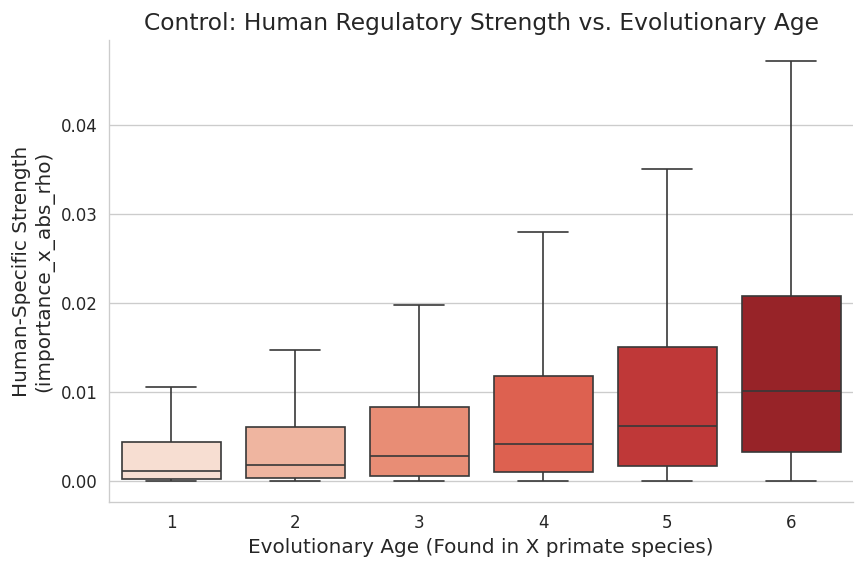

In [18]:
# 1. Isolate just the Human records
human_links = None
for run_key, result in all_run_results.items():
    if run_key == "Human_original":
        human_links = result["ereg_annotated"].dropna(subset=["peak_id", "target_gene", STRENGTH_METRIC])
        break

if human_links is not None:
    # Get the max strength for each link IN HUMAN
    human_strength = human_links.groupby(["peak_id", "target_gene"])[STRENGTH_METRIC].max().reset_index()
    human_strength.rename(columns={STRENGTH_METRIC: "human_strength"}, inplace=True)
    
    # 2. Merge with the conservation counts we already calculated in the previous script
    control_df = human_strength.merge(
        link_conservation[["peak_id", "target_gene", "species_count"]], 
        on=["peak_id", "target_gene"], 
        how="inner"
    )
    
    # 3. Plot
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.boxplot(
        data=control_df, 
        x="species_count", 
        y="human_strength", 
        palette="Reds",
        showfliers=False, # Hide outliers to see the medians clearly
        ax=ax
    )
    
    ax.set_title("Control: Human Regulatory Strength vs. Evolutionary Age", fontsize=14)
    ax.set_xlabel("Evolutionary Age (Found in X primate species)", fontsize=12)
    ax.set_ylabel(f"Human-Specific Strength\n({STRENGTH_METRIC})", fontsize=12)
    sns.despine()
    plt.show()
else:
    print("Could not find the 'Human_original' run.")

In [26]:
human_ereg.loc[human_ereg['peak_type']=='human_specific'].sort_values(by='rho_R2G')

,region,target_gene,importance_R2G,rho_R2G,importance_x_rho,importance_x_abs_rho,TF,is_extended,eRegulon_name,Gene_signature_name,Region_signature_name,importance_TF2G,regulation,rho_TF2G,triplet_rank,annotation_type,peak_id,peak_type
190782,chr17:951539-952039,ABR,0.000849,-0.300405,-0.000255,0.000255,EHF,False,EHF_direct_+/-,EHF_direct_+/-_(878g),EHF_direct_+/-_(2139r),4.913657,1,0.303700,61199,direct,human_peak_001190,human_specific
199130,chr17:951539-952039,ABR,0.000849,-0.300405,-0.000255,0.000255,HMGA2,False,HMGA2_direct_+/-,HMGA2_direct_+/-_(518g),HMGA2_direct_+/-_(696r),12.385569,1,0.331569,35407,direct,human_peak_001190,human_specific
216392,chr17:951539-952039,ABR,0.000849,-0.300405,-0.000255,0.000255,PPARG,False,PPARG_direct_+/-,PPARG_direct_+/-_(347g),PPARG_direct_+/-_(450r),4.468646,1,0.333515,56036,direct,human_peak_001190,human_specific
399359,chr17:951539-952039,ABR,0.000849,-0.300405,-0.000255,0.000255,KLF5,True,KLF5_extended_+/-,KLF5_extended_+/-_(1146g),KLF5_extended_+/-_(2399r),4.624497,1,0.307356,65568,extended,human_peak_001190,human_specific
214323,chr7:154676361-154676861,DPP6,0.006211,-0.259940,-0.001614,0.001614,MITF,False,MITF_direct_+/-,MITF_direct_+/-_(23g),MITF_direct_+/-_(24r),1.625471,1,0.359171,13113,direct,human_peak_002808,human_specific
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
231289,chr4:118793380-118793880,SYNPO2,0.001388,0.667403,0.000926,0.000926,ELF3,False,ELF3_direct_-/+,ELF3_direct_-/+_(362g),ELF3_direct_-/+_(2043r),0.812978,-1,-0.300537,50959,direct,human_peak_002362,human_specific
235610,chr4:118793380-118793880,SYNPO2,0.001388,0.667403,0.000926,0.000926,FLI1,False,FLI1_direct_-/+,FLI1_direct_-/+_(243g),FLI1_direct_-/+_(2247r),0.860452,-1,-0.058477,50773,direct,human_peak_002362,human_specific
412739,chr4:118793380-118793880,SYNPO2,0.001388,0.667403,0.000926,0.000926,FLI1,True,FLI1_extended_-/+,FLI1_extended_-/+_(213g),FLI1_extended_-/+_(1447r),0.860452,-1,-0.058477,31320,extended,human_peak_002362,human_specific
406553,chr4:118793380-118793880,SYNPO2,0.001388,0.667403,0.000926,0.000926,EHF,True,EHF_extended_-/+,EHF_extended_-/+_(239g),EHF_extended_-/+_(1413r),0.518775,-1,-0.291322,33806,extended,human_peak_002362,human_specific


In [20]:
import pandas as pd
from IPython.display import display

# Make sure we use the same metric
STRENGTH_METRIC = "importance_x_abs_rho"
human_run_key = "Human_original"

if human_run_key in all_run_results:
    human_ereg = all_run_results[human_run_key]["ereg_annotated"]
    
    # 1. Filter for strictly human-specific peaks
    human_specific_df = human_ereg[human_ereg["peak_type"] == "human_specific"].copy()
    
    # Drop any rows missing critical data
    human_specific_df = human_specific_df.dropna(subset=[STRENGTH_METRIC, "target_gene", "TF", "peak_id"])
    
    # 2. Sort to find the absolute strongest links
    top_human_specific = human_specific_df.sort_values(by=STRENGTH_METRIC, ascending=False)
    
    # A single region might be called by both 'direct' and 'extended' annotations. 
    # We drop duplicates so we don't clog the top 20 list with the exact same interaction twice.
    top_human_specific = top_human_specific.drop_duplicates(subset=["peak_id", "target_gene", "TF"])
    
    # Select the most readable columns
    display_cols = ["TF", "target_gene", "peak_id", "region", STRENGTH_METRIC, "annotation_type"]
    
    print(f"\n{'='*85}")
    print(f"TOP 20 STRONGEST HUMAN-SPECIFIC ENHANCER-GENE LINKS")
    print(f"{'='*85}")
    display(top_human_specific[display_cols].head(20))
    
    # 3. Aggregate: Which TFs are dominating these newly evolved, high-strength networks?
    top_100_links = top_human_specific.head(100)
    top_tfs = top_100_links["TF"].value_counts().head(10)
    
    print("\n" + "-"*50)
    print("TFs Driving the Top 100 Strongest Human-Specific Links:")
    print("-"*50)
    
    tf_summary = top_tfs.reset_index()
    tf_summary.columns = ["Transcription Factor", "Number of Top 100 Links"]
    display(tf_summary)

else:
    print(f"Could not find '{human_run_key}' in the results dictionary.")


TOP 20 STRONGEST HUMAN-SPECIFIC ENHANCER-GENE LINKS


,TF,target_gene,peak_id,region,importance_x_abs_rho,annotation_type
97969,KLF3,MAOA,human_peak_003102,chrX:43586681-43587181,0.037490,direct
65609,HNF4A,MAOA,human_peak_003102,chrX:43586681-43587181,0.037490,direct
112813,KLF5,MAOA,human_peak_003102,chrX:43586681-43587181,0.037490,direct
79269,HNF4G,MAOA,human_peak_003102,chrX:43586681-43587181,0.037490,direct
147930,PPARG,MAOA,human_peak_003102,chrX:43586681-43587181,0.037490,direct
138099,PPARA,SULT1B1,human_peak_002335,chr4:69775233-69775733,0.030421,direct
319208,HNF4A,SULT1B1,human_peak_002335,chr4:69775233-69775733,0.030421,extended
372907,PPARG,SULT1B1,human_peak_002335,chr4:69775233-69775733,0.030421,extended
327298,HNF4G,SULT1B1,human_peak_002335,chr4:69775233-69775733,0.030421,extended
262995,ZEB1,SULT1B1,human_peak_002335,chr4:69775233-69775733,0.030421,direct



--------------------------------------------------
TFs Driving the Top 100 Strongest Human-Specific Links:
--------------------------------------------------


,Transcription Factor,Number of Top 100 Links
0,HNF4G,13
1,KLF5,11
2,HNF4A,9
3,KLF3,7
4,PPARG,7
5,ZEB1,4
6,ELF3,4
7,TCF12,3
8,IKZF1,3
9,MAF,3


## Cross-run robustness analysis (multiple seeds)

Compare eRegulon region sets across different seeds for the same species — how reproducible are the identified enhancers?

In [ ]:
# Group runs by species
from collections import defaultdict
species_runs = defaultdict(list)
for run_key, result in all_run_results.items():
    species = run_key.split("_")[0]
    species_runs[species].append((run_key, result))

for species, runs in species_runs.items():
    if len(runs) < 2:
        continue
    
    print(f"\n{'='*60}")
    print(f"  {species}: comparing {len(runs)} runs")
    print(f"{'='*60}")
    
    # Jaccard similarity of region sets
    run_keys = [rk for rk, _ in runs]
    region_sets = {rk: result["unique_regions"] for rk, result in runs}
    
    jaccard_matrix = pd.DataFrame(index=run_keys, columns=run_keys, dtype=float)
    for rk1, rk2 in combinations(run_keys, 2):
        s1, s2 = region_sets[rk1], region_sets[rk2]
        intersection = len(s1 & s2)
        union = len(s1 | s2)
        j = intersection / union if union > 0 else 0.0
        jaccard_matrix.loc[rk1, rk2] = j
        jaccard_matrix.loc[rk2, rk1] = j
    for rk in run_keys:
        jaccard_matrix.loc[rk, rk] = 1.0
    
    print("\nJaccard similarity of enhancer region sets:")
    display(jaccard_matrix.style.format("{:.3f}").background_gradient(cmap="YlGn", vmin=0, vmax=1))
    
    # Regions found in ALL runs
    all_region_sets = [region_sets[rk] for rk in run_keys]
    consensus_regions = set.intersection(*all_region_sets)
    any_regions = set.union(*all_region_sets)
    print(f"\n  Regions in ALL runs: {len(consensus_regions):,}")
    print(f"  Regions in ANY run:  {len(any_regions):,}")
    print(f"  Reproducibility:     {len(consensus_regions)/len(any_regions):.1%}" if any_regions else "")

## Overall summary

In [ ]:
if len(stats_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Mapping rate per run
    ax = axes[0]
    sns.barplot(data=stats_df, x="species", y="pct_mapped", hue="run_label",
                ax=ax, palette="Set2")
    ax.axhline(90, ls="--", color="red", alpha=0.7)
    ax.set_ylabel("% enhancers mapped to consensus")
    ax.set_title("eRegulon enhancer → consensus peak mapping")
    ax.set_ylim(0, 105)
    
    # Plot 2: Number of enhancers per run
    ax = axes[1]
    sns.barplot(data=stats_df, x="species", y="n_unique_regions", hue="run_label",
                ax=ax, palette="Set2")
    ax.set_ylabel("Unique enhancer regions")
    ax.set_title("Number of eRegulon enhancers per run")
    
    plt.tight_layout()
    plt.show()

print("\nAnnotated eRegulon files saved to:", OUTPUT_DIR)
print("Done.")